In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import tqdm

import mne
from mne.io import concatenate_raws, read_raw_edf
import numpy as np

from bscarlos.settings import RAW_KISPI_DATA_FOLDER
from bscarlos.settings import PROCESSED_KISPI_DATA_FOLDER

## EDA 
Here we explore the EEG data from KISPI patients.  We first get a general sense of the data, length of each recording and number of (single & bipolar) channels.  The next steps will be to analyze the data with more statsitical methods, for this in particular we explore `tsfresh` package which is used to perform feature engineering on time-series and other sequential data<sup>1</sup> similar to ours.


--- 


[1] Christ, M., Braun, N., Neuffer, J. and Kempa-Liehr A.W. (2018). Time Series FeatuRe Extraction on basis of Scalable Hypothesis tests (tsfresh – A Python package). Neurocomputing 307 (2018) 72-77, doi: 10.1016/j.neucom.2018.03.067.

### Convert .edf to parquet files
In order to better handle the dataset it would be advantagous to create a dataframe using trusty `pandas`, however we first needed to convert our EEG files from .edf format into parquet files.  To accomplish this we used the `edf2parquet` a simple utility package to convert EDF/EDF+ files into Apache Parquet format while preserving the EDF file header information and signal headers metadata information then we will be able to read the files directly<sup>2</sup>. We specifically used the built-in `AdvancedEdfToParquetConverter` class to convert the files and utilize the `exclude_singals` argument to exclude the following list of signals ["EEG A1", "EEG A2", "EKG", "EOG", "EMG", "PHO"].  In addition we create a data_attributes.csv file with all the important attributes we unvail.

---


[2] [edf2parquet repository](https://github.com/NarayanSchuetz/edf2parquet/tree/main)

In [2]:
import pytz
from edf2parquet.converters import AdvancedEdfToParquetConverter


test_edf_file = "C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\raw_kispi\\SE008_120418U-A.edf"  # REPLACE WITH YOUR EDF FILE PATH
test_parquet_output_dir = "C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\raw_kispi"  # REPLACE WITH YOUR PARQUET OUTPUT DIRECTORY

test_converter = AdvancedEdfToParquetConverter(edf_file_path=test_edf_file,  # path to the EDF file
                                          exclude_signals=["Audio"],  # list of signals to exclude from the conversion
                                          parquet_output_dir=test_parquet_output_dir,  # path to the output directory (will be created if not exists)
                                          group_by_sampling_freq=True,  # whether to group signals with same sampling frequency into single parquet files
                                          datetime_index=True,  # whether to automatically add a pd.DatetimeIndex to the resulting parquet files
                                          local_timezone=(pytz.timezone("Europe/Zurich"), pytz.timezone("Europe/Zurich")),  # specifies the timezone of the EDF file and the timezone of the start_date in the EDF file (should be the same for most cases)
                                          compression_codec="GZIP" # compression codec to use for the resulting parquet files
                                          )

test_converter.convert()

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N' is deprecated and will be removed in a future version, please use 'ns' instead.
  time_points = pd.date_range(


#### To do:
- [ ] correct filename output, figure out how to extract 'admin_name' from metadata to use SE008, SE021, etc. naming

In [5]:
import os
from tqdm import tqdm

# Define the input and output folders
input_folder = RAW_KISPI_DATA_FOLDER
output_folder = PROCESSED_KISPI_DATA_FOLDER

# Create the output folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Get a list of all .edf files in the input folder
filenames = [filename for filename in os.listdir(input_folder) if filename.endswith('.edf')]

# Iterate and convert all .edf files
for filename in tqdm(filenames, desc='Converting EDF to Parquet'):
    # Split the filename at '_' and use the first part as the output filename
    output_filename = filename.split('_')[0] + '.parquet'

    # Create the full output file path
    output_file_path = os.path.join(output_folder, output_filename)

    # Create an instance of the converter
    converter = AdvancedEdfToParquetConverter(
        edf_file_path=os.path.join(input_folder, filename),
        parquet_output_dir=output_folder,
        exclude_signals=["EEG A1", "EEG A2", "EKG", "EOG", "EMG", "PHO"],
        group_by_sampling_freq=True,
        datetime_index=True,
        local_timezone=(pytz.timezone("Europe/Zurich"), pytz.timezone("Europe/Zurich")),
        compression_codec="GZIP"
    )
    
    # Convert the EDF file to Parquet and save it to the output folder
    converter.convert()

Converting EDF to Parquet:   0%|          | 0/4 [00:00<?, ?it/s]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:173: UserWarning: Unable to read .EDF file: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE008_120418U-A.edf: file has already been opened. Attempting to correct the header.
  warnings.warn(f"Unable to read .EDF file: {e}. Attempting to correct the header.")
c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N' is deprecated and will be removed in a future version, please use 'ns' instead.
  time_points = pd.date_range(
Converting EDF to Parquet:  25%|██▌       | 1/4 [00:46<02:20, 46.79s/it]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N'

#### Read a converted Parquet file using handy pandas.

In [6]:
# abolute path to the parquet file
my_parquet_file_path = "C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\raw_kispi\\56391_2012-04-17_256.0.parquet"

# create dataframe from parquet file
df = pd.read_parquet(my_parquet_file_path)

#### Read a converted Parqeut file using the ParquetReader class directly

In [7]:
from edf2parquet.readers import ParquetReader

reader = ParquetReader(parquet_file_path=my_parquet_file_path)
df = reader.get_pandas_dataframe(set_timezone=True) # (Note that here we set a timezone which is different to when we used plain pandas)

In [8]:
reader.get_file_header()

{'technician': '',
 'recording_additional': '',
 'patientname': 'X',
 'patient_additional': '',
 'patientcode': '56391',
 'equipment': 'Deltamed',
 'admincode': 'SE008 120418U-A',
 'sex': '',
 'startdate': Timestamp('2012-04-17 17:02:08+0200', tz='Europe/Zurich'),
 'birthdate': '',
 'gender': '',
 'tz_recording': 'Europe/Zurich',
 'tz_startdatetime': 'Europe/Zurich'}

In [9]:
reader.get_signal_headers()

[{'label': 'EEG Fp1',
  'dimension': 'uV',
  'sample_rate': 256.0,
  'sample_frequency': 256.0,
  'physical_max': 5865.0,
  'physical_min': -5865.0,
  'digital_max': 32767,
  'digital_min': -32768,
  'prefilter': 'HP:10Hz LP:100Hz',
  'transducer': 'AgAgCl electrode'},
 {'label': 'EEG Fp2',
  'dimension': 'uV',
  'sample_rate': 256.0,
  'sample_frequency': 256.0,
  'physical_max': 5865.0,
  'physical_min': -5865.0,
  'digital_max': 32767,
  'digital_min': -32768,
  'prefilter': 'HP:10Hz LP:100Hz',
  'transducer': 'AgAgCl electrode'},
 {'label': 'EEG F7',
  'dimension': 'uV',
  'sample_rate': 256.0,
  'sample_frequency': 256.0,
  'physical_max': 5865.0,
  'physical_min': -5865.0,
  'digital_max': 32767,
  'digital_min': -32768,
  'prefilter': 'HP:10Hz LP:100Hz',
  'transducer': 'AgAgCl electrode'},
 {'label': 'EEG F3',
  'dimension': 'uV',
  'sample_rate': 256.0,
  'sample_frequency': 256.0,
  'physical_max': 5865.0,
  'physical_min': -5865.0,
  'digital_max': 32767,
  'digital_min': -3

In [10]:
new_parquet_file_path ="C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\processed_kispi\\56391_2012-04-17_256.0.parquet"

In [11]:
df = pd.read_parquet(new_parquet_file_path)
# Print the shape of dataframe
print(df.shape)

# Print the first 5 rows
print(df.head())

# Print column names and their data types
print(df.info())

# Get summary statistics of numerical columns
print(df.describe())

(15010560, 19)
                               EEG Fp1    EEG Fp2      EEG F7      EEG F3  \
2012-04-17 17:02:08.000000  107.303505  78.486382  163.326843  136.478592   
2012-04-17 17:02:08.003906  107.303505  78.665367  164.400772  136.120621   
2012-04-17 17:02:08.007812  108.914398  80.634239  167.980545  138.626465   
2012-04-17 17:02:08.011718  108.914398  80.992218  167.443573  138.805450   
2012-04-17 17:02:08.015625  108.556419  81.529182  166.727631  137.552536   

                              EEG Fz      EEG F4      EEG F8      EEG T3  \
2012-04-17 17:02:08.000000 -6.354085  123.591438  143.638138  102.649803   
2012-04-17 17:02:08.003906 -6.354085  121.622566  142.922180  101.217896   
2012-04-17 17:02:08.007812 -5.996109  123.412453  145.428009  103.723732   
2012-04-17 17:02:08.011718 -5.459144  123.591438  146.143967  102.470818   
2012-04-17 17:02:08.015625 -3.311284  124.486382  145.964981  101.575874   

                               EEG C3     EEG Cz      EEG C4    E

### Analyze the mean and standard devitation for each channel within the data frame

In [12]:
def analyze_eeg(df, window_size=2.5):
  """
  Analyzes EEG data to calculate the mean and standard deviation for each channel
  within a specified window.

  Args:
    df: A Pandas DataFrame with the EEG data, where the index is a datetime object.
    window_size: The size of the analysis window in seconds.

  Returns:
    A tuple containing two Pandas DataFrames:
      - mean_df: A DataFrame containing the mean value for each channel in each window.
      - std_df: A DataFrame containing the standard deviation for each channel in each window.
  """

  sampling_rate = 1 / (df.index[1] - df.index[0]).total_seconds()
  window_samples = int(window_size * sampling_rate)
  num_windows = len(df) // window_samples

  mean_values = []
  std_values = []

  for i in range(num_windows):
    start = i * window_samples
    end = start + window_samples
    window_data = df.iloc[start:end]
    mean_values.append(window_data.mean())
    std_values.append(window_data.std())

  mean_df = pd.DataFrame(mean_values)
  std_df = pd.DataFrame(std_values)

  return mean_df, std_df


# ensure the DataFrame index is a DatetimeIndex
if not isinstance(df.index, pd.DatetimeIndex):
  df.index = pd.to_datetime(df.index)

# analyze the EEG data
mean_df, std_df = analyze_eeg(df)

# print the results
print("Mean values for each channel and window:")
print(mean_df)

print("\nStandard deviation values for each channel and window:")
print(std_df)

Mean values for each channel and window:
          EEG Fp1    EEG Fp2      EEG F7      EEG F3     EEG Fz      EEG F4  \
0      104.490311  81.048988  168.185547  131.014435  -3.387913  143.956116   
1      101.322495  77.842865  165.068359  123.859360  -4.749622  146.704987   
2      101.806885  77.185921  166.126053  129.550919  -6.180691  134.438141   
3      101.510147  81.130089  164.792313  126.359047  -1.801629  148.627991   
4      103.663895  74.153748  169.144257  127.124222  -7.709083  135.426758   
...           ...        ...         ...         ...        ...         ...   
23449    0.089494   0.089494    0.089494    0.089494   0.089494    0.089494   
23450    0.089494   0.089494    0.089494    0.089494   0.089494    0.089494   
23451   56.168213  25.159044   74.161011   -7.430253   4.991257   51.470612   
23452  202.376511  92.613594  266.055237  -49.133980  12.202807  180.367096   
23453  113.926346  19.148117  210.915649   42.240131  15.794601   75.397995   

          

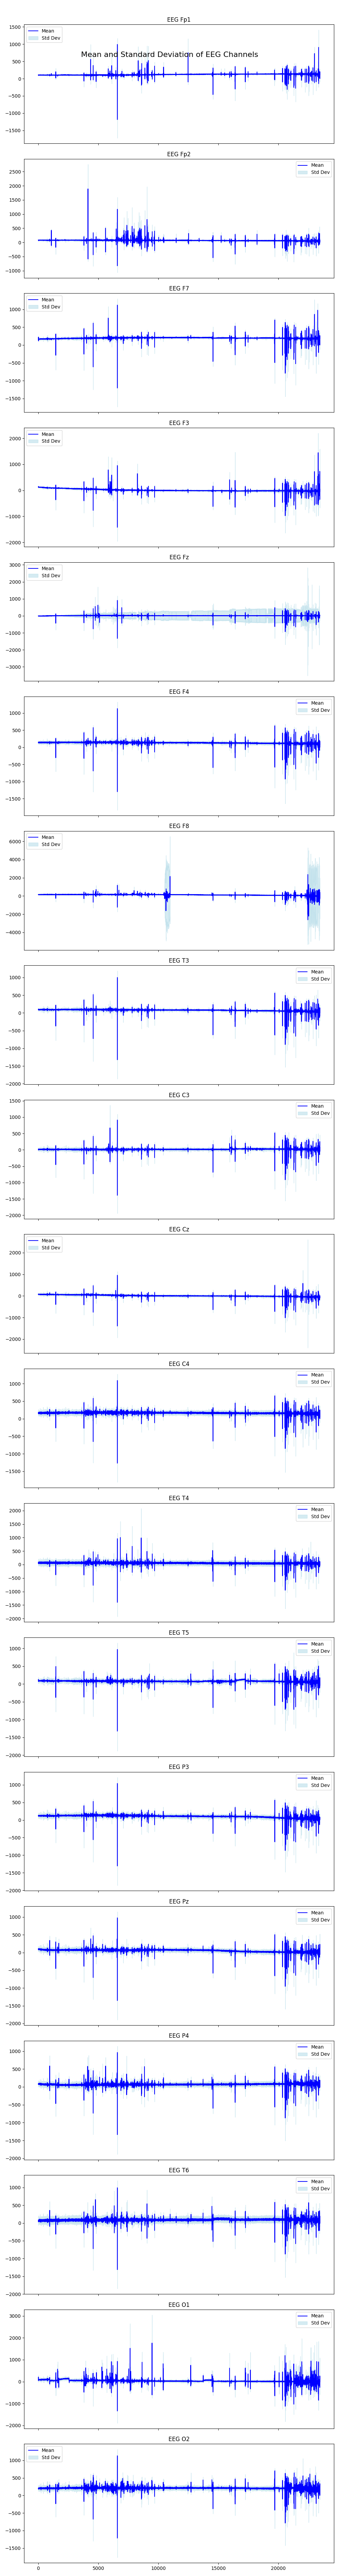

In [13]:
channels = mean_df.columns
mean_values = mean_df.values
std_values = std_df.values
num_channels = len(channels)

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 4 * num_channels), sharex=True)
fig.suptitle('Mean and Standard Deviation of EEG Channels', fontsize=16)

for i in range(num_channels):
    axes[i].plot(mean_values[:, i], color='blue', label='Mean')
    axes[i].fill_between(
        range(len(mean_values)),
        mean_values[:, i] - std_values[:, i],
        mean_values[:, i] + std_values[:, i],
        color='lightblue',
        alpha=0.5,
        label='Std Dev'
    )
    axes[i].set_title(channels[i])
    axes[i].legend()

plt.tight_layout()
plt.show()

In [19]:
print(df.columns)
print(df.head())

Index(['EEG Fp1', 'EEG Fp2', 'EEG F7', 'EEG F3', 'EEG Fz', 'EEG F4', 'EEG F8',
       'EEG T3', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG T4', 'EEG T5', 'EEG P3',
       'EEG Pz', 'EEG P4', 'EEG T6', 'EEG O1', 'EEG O2'],
      dtype='object')
                               EEG Fp1    EEG Fp2      EEG F7      EEG F3  \
2012-04-17 17:02:08.000000  107.303505  78.486382  163.326843  136.478592   
2012-04-17 17:02:08.003906  107.303505  78.665367  164.400772  136.120621   
2012-04-17 17:02:08.007812  108.914398  80.634239  167.980545  138.626465   
2012-04-17 17:02:08.011718  108.914398  80.992218  167.443573  138.805450   
2012-04-17 17:02:08.015625  108.556419  81.529182  166.727631  137.552536   

                              EEG Fz      EEG F4      EEG F8      EEG T3  \
2012-04-17 17:02:08.000000 -6.354085  123.591438  143.638138  102.649803   
2012-04-17 17:02:08.003906 -6.354085  121.622566  142.922180  101.217896   
2012-04-17 17:02:08.007812 -5.996109  123.412453  145.428009  103.723732 

#### Create bipolar channel pairs 

In [20]:
# create bipolar channels from the original channels
def create_bipolar_channels(df):
  """
  Creates bipolar channels from the original channels.

  Args:
    df: A Pandas DataFrame with the EEG data, where the index is a datetime object.

  Returns:
    A DataFrame with bipolar channels.
  """

  # create list of bipolar pairs
  bipolar_pairs = [
      ('Fp1-F7', 'EEG Fp1', 'EEG F7'),
      ('F7-T3', 'EEG F7', 'EEG T3'),
      ('T3-T5', 'EEG T3', 'EEG T5'),
      ('Fp1-F3', 'EEG Fp1', 'EEG F3'),
      ('F3-C3', 'EEG F3', 'EEG C3'),
      ('C3-P3', 'EEG C3', 'EEG P3'),
      ('P3-O1', 'EEG P3', 'EEG O1'),
      ('Fz-Cz', 'EEG Fz', 'EEG Cz'),
      ('Cz-Pz', 'EEG Cz', 'EEG Pz'),
      ('Fp2-F4', 'EEG Fp2', 'EEG F4'),
      ('F4-C4', 'EEG F4', 'EEG C4'),
      ('C4-P4', 'EEG C4', 'EEG P4'),
      ('P4-O2', 'EEG P4', 'EEG O2'),
      ('Fp2-F8', 'EEG Fp2', 'EEG F8'),
      ('F8-T4', 'EEG F8', 'EEG T4'),
      ('T4-T6', 'EEG T4', 'EEG T6'),
      ('T6-O2', 'EEG T6', 'EEG O2'),
  ]

  # create a new empty DataFrame
  bipolar_df = pd.DataFrame(index=df.index)

  for pair in bipolar_pairs:
      # strip any leading/trailing spaces from column names
      ch1 = pair[1].strip()  
      ch2 = pair[2].strip()

      if ch1 in df.columns and ch2 in df.columns:
          bipolar_df[pair[0]] = df[ch1] - df[ch2]
      else:
          print(f"Warning: Channel(s) missing for pair {pair[0]}")

  return bipolar_df

bipolar_df = create_bipolar_channels(df)

print(bipolar_df.head())
  

                               Fp1-F7      F7-T3      T3-T5     Fp1-F3  \
2012-04-17 17:02:08.000000 -56.023338  60.677040 -19.330742 -29.175087   
2012-04-17 17:02:08.003906 -57.097267  63.182877 -18.435799 -28.817116   
2012-04-17 17:02:08.007812 -59.066147  64.256813 -15.214012 -29.712067   
2012-04-17 17:02:08.011718 -58.529175  64.972755 -15.929962 -29.891052   
2012-04-17 17:02:08.015625 -58.171211  65.151756 -18.614784 -28.996117   

                                F3-C3      C3-P3      P3-O1      Fz-Cz  \
2012-04-17 17:02:08.000000  95.042793 -97.369652  74.817123 -90.747086   
2012-04-17 17:02:08.003906  96.653694 -95.758751  73.743187 -87.704285   
2012-04-17 17:02:08.007812  98.801559 -95.937744  76.249031 -87.883270   
2012-04-17 17:02:08.011718  99.696503 -97.011673  77.680931 -87.883270   
2012-04-17 17:02:08.015625  98.622574 -98.801559  77.501953 -87.704285   

                                Cz-Pz     Fp2-F4      F4-C4      C4-P4  \
2012-04-17 17:02:08.000000  11.27626

In [21]:
print(bipolar_df.columns)
print(bipolar_df.shape)

Index(['Fp1-F7', 'F7-T3', 'T3-T5', 'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
       'Fz-Cz', 'Cz-Pz', 'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'Fp2-F8',
       'F8-T4', 'T4-T6', 'T6-O2'],
      dtype='object')
(15010560, 17)


#### Anaylze bipolar channels

In [28]:
# Analyze the EEG data
mean_bipolar_df, std_bipolar_df = analyze_eeg(bipolar_df)

# Print the results
print("Mean values for each bipolar channel and window:")
print(mean_bipolar_df)

print("\nStandard deviation values for each bipolar channel and window:")
print(std_bipolar_df)

Mean values for each bipolar channel and window:
          Fp1-F7       F7-T3       T3-T5      Fp1-F3       F3-C3       C3-P3  \
0     -63.695232   66.418930   -2.945477  -26.524113  108.211586 -107.164505   
1     -63.745850   80.407150    7.976726  -22.536869  113.632706 -106.858841   
2     -64.319176   62.611794  -13.977590  -27.744030  104.443039 -102.442284   
3     -63.282158   69.527176   -4.761090  -24.848894  106.077148 -108.280396   
4     -65.480362   70.486435    2.262804  -23.460335  110.297363 -100.235985   
...          ...         ...         ...         ...         ...         ...   
23449   0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
23450   0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
23451 -17.992802   44.745960  -28.267849   63.598469    3.680168  -21.850559   
23452 -63.678734  123.267014  -33.590797  251.510498    1.672702  -80.844833   
23453 -96.989304  187.222076  118.934387   71.686226  -35.057941    2.3

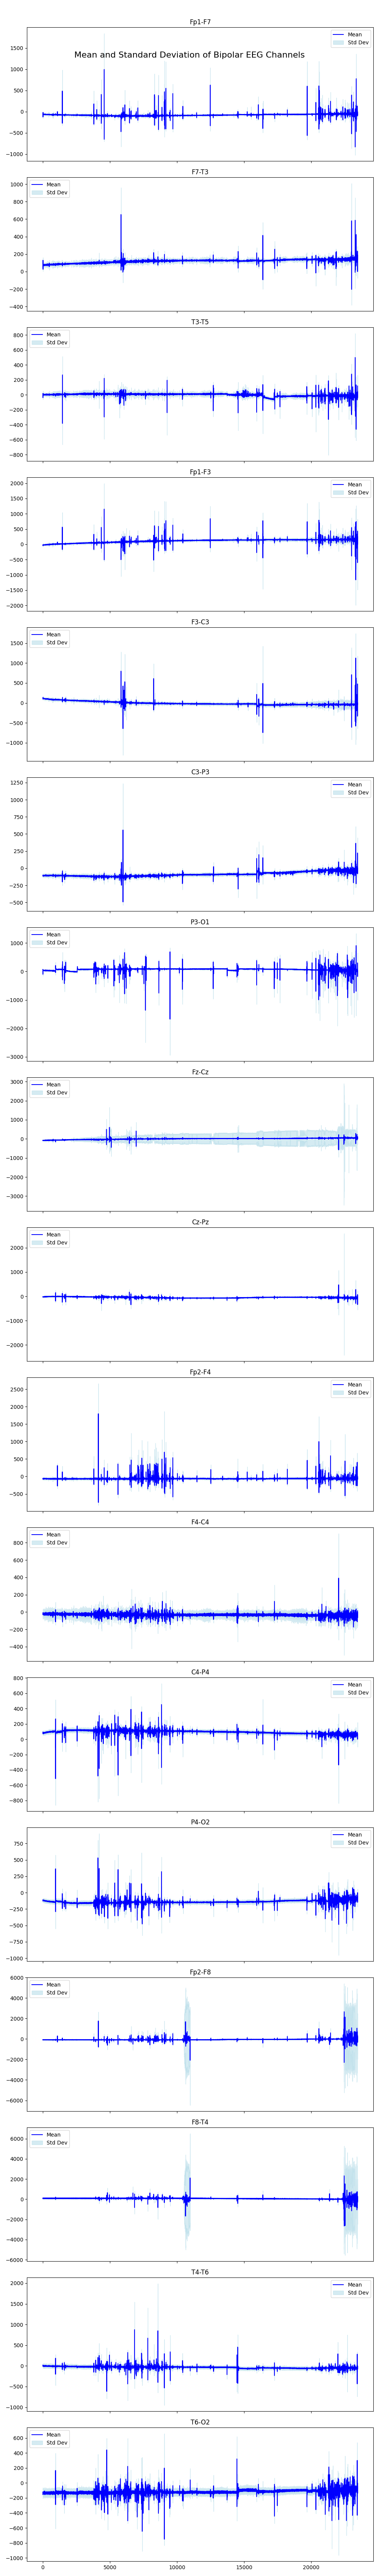

In [29]:
channels = mean_bipolar_df.columns
mean_values = mean_bipolar_df.values
std_values = std_bipolar_df.values
num_channels = len(channels)

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 4 * num_channels), sharex=True)
fig.suptitle('Mean and Standard Deviation of Bipolar EEG Channels', fontsize=16)

for i in range(num_channels):
    axes[i].plot(mean_values[:, i], color='blue', label='Mean')
    axes[i].fill_between(
        range(len(mean_values)),
        mean_values[:, i] - std_values[:, i],
        mean_values[:, i] + std_values[:, i],
        color='lightblue',
        alpha=0.5,
        label='Std Dev'
    )
    axes[i].set_title(channels[i])
    axes[i].legend()

plt.tight_layout()
plt.show()

#### TO DO: 
- [ ] with the following code make a data_attributes.csv file 

In [40]:
# create a data_attributes.csv file from the data

def create_data_attributes_csv(parquet_file, output_csv_path, patient_counter):
  """
  Creates a CSV file named 'data_attributes_kispi.csv' from a Parquet file 
  containing patient data.

  Args:
    parquet_file: Path to the Parquet file.  
    output_csv_path: Path to the output CSV file.
    patient_counter: An integer representing the current patient number.
  """

  reader = ParquetReader(parquet_file)
  file_header = reader.get_file_header()
  signal_headers = reader.get_signal_headers()

  # extract patient ID and start date
  patient_id = file_header['admincode'].split('_')[0]
  start_datetime = file_header['startdate'].strftime('%Y-%m-%d %H:%M:%S')

  # get end sample and sample rate
  df = pd.read_parquet(parquet_file)
  end_sample = df.index[-1] # get last datetime index
  sample_rate = signal_headers[0]['sample_rate']

  # create a dictionary with patient ID, start date, end sample, and sample rate
  data_attributes = {
      'unique_patient_id': patient_id,
      'patient_id': f"P{patient_counter}",
      'start_datetime': start_datetime,
      'end_sample': end_sample,
      'sample_rate': sample_rate
      }
  
  # create a DataFrame from the dictionary
  data_attributes_df = pd.DataFrame(data_attributes, index=[0])

  # save the DataFrame to a CSV file
  data_attributes_df.to_csv(output_csv_path, index=False)

  print(f"Data attributes saved to {output_csv_path}")

In [41]:
my_parquet_file_path = "C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\raw_kispi\\56391_2012-04-17_256.0.parquet"
output_file_path = PROCESSED_KISPI_DATA_FOLDER
patient_counter = 1

create_data_attributes_csv(my_parquet_file_path, output_file_path, patient_counter)

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\c_arz\\Documents\\KISPI\\Burst_Suppression_Project\\Thesis\\UnsuperDL-EEG-BSUPP\\data\\processed_kispi'

#### Read parquet files and create patient_data dictionary

In [ ]:
from bscarlos.data.data_preprocessing import DataPreprocessing

data_preprocess = DataPreprocessing()

data_files = sorted(list(PROCESSED_KISPI_DATA_FOLDER.glob("*.parquet")))

patient_data = data_preprocess.create_patient_data_dict(data_files, data_attributes=None)

patient_data.keys()


  0%|          | 0/4 [00:00<?, ?it/s]


AttributeError: 'NoneType' object has no attribute 'loc'